<a href="https://colab.research.google.com/github/ANJALICHAMOLI/Deep-Learning/blob/main/batch_norm.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

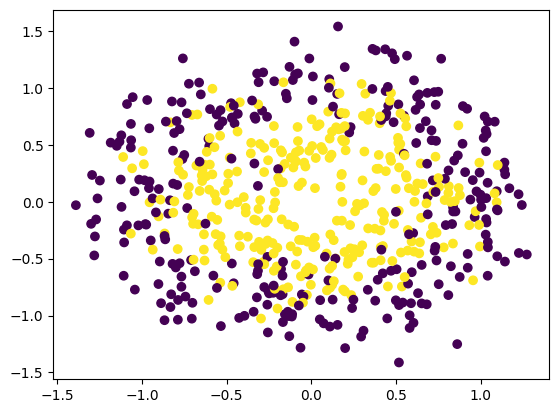

In [ ]:

from sklearn.datasets import make_circles
import pandas as pd
import matplotlib.pyplot as plt

# BRUTAL dataset — nearly impossible without batch norm
X, y = make_circles(
    n_samples=600,
    noise=0.22,     # middle ground — not too easy, not too hard
    factor=0.62,
    random_state=42
)

df = pd.DataFrame({'X': X[:,0], 'Y': X[:,1], 'class': y})

plt.scatter(df['X'], df['Y'], c=df['class'])
plt.show()

# Expected behaviour when training:
# - Without BN: val_accuracy stuck ~0.50, dips, never really learns
# - With BN:    slowly climbs from ~0.50 to ~0.62-0.68 over 200 epochs


In [ ]:
df.head()

,X,Y,class
0,-0.473554,0.852279,0
1,-0.481623,0.388103,1
2,0.144068,-0.499228,1
3,0.153089,0.947708,0
4,-0.786773,-0.863347,0


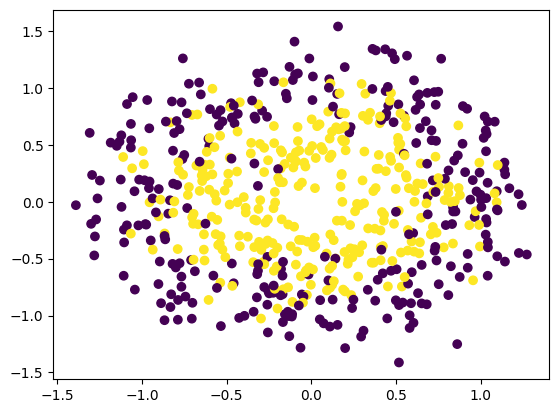

In [ ]:
plt.scatter(df['X'],df['Y'],c=df['class'])

In [ ]:
X = df.iloc[:,0:2].values
y = df.iloc[:,-1].values

In [ ]:
import tensorflow
from tensorflow import keras
from keras import Sequential
from keras.layers import Dense
from tensorflow.keras.layers import BatchNormalization

Not using batch normlaization

In [ ]:
model = Sequential()

model.add(Dense(2,activation='relu',input_dim=2))
model.add(Dense(2,activation='relu'))
model.add(Dense(1,activation='sigmoid'))

model.summary()

/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential_6"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_18 (Dense)                │ (None, 2)              │             6 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_19 (Dense)                │ (None, 2)              │             6 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_20 (Dense)                │ (None, 1)              │             3 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 15 (60.00 B)

 Trainable params: 15 (60.00 B)

 Non-trainable params: 0 (0.00 B)

In [ ]:
model.compile(loss='binary_crossentropy',optimizer='adam',metrics=['accuracy'])

In [ ]:
history1 = model.fit(X,y,epochs=200,validation_split=0.2)

Epoch 1/200
15/15 ━━━━━━━━━━━━━━━━━━━━ 1s 19ms/step - accuracy: 0.4708 - loss: 0.6933 - val_accuracy: 0.5083 - val_loss: 0.6931
Epoch 2/200
15/15 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - accuracy: 0.4979 - loss: 0.6932 - val_accuracy: 0.5083 - val_loss: 0.6931
Epoch 3/200
15/15 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - accuracy: 0.4979 - loss: 0.6932 - val_accuracy: 0.5083 - val_loss: 0.6931
Epoch 4/200
15/15 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - accuracy: 0.4979 - loss: 0.6932 - val_accuracy: 0.5083 - val_loss: 0.6931
Epoch 5/200
15/15 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - accuracy: 0.4979 - loss: 0.6932 - val_accuracy: 0.5083 - val_loss: 0.6931
Epoch 6/200
15/15 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - accuracy: 0.4646 - loss: 0.6932 - val_accuracy: 0.4917 - val_loss: 0.6931
Epoch 7/200
15/15 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - accuracy: 0.4854 - loss: 0.6932 - val_accuracy: 0.5083 - val_loss: 0.6931
Epoch 8/200
15/15 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.4729 - loss: 0.6932 - val_accuracy: 0.4917 - 

using batch normalization

In [ ]:
model1 = Sequential()

model1.add(Dense(3,activation='relu',input_dim=2))
model1.add(BatchNormalization())
model1.add(Dense(2,activation='relu'))
model1.add(BatchNormalization())
model1.add(Dense(1,activation='sigmoid'))

model1.summary()

Model: "sequential_7"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_21 (Dense)                │ (None, 3)              │             9 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_6           │ (None, 3)              │            12 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_22 (Dense)                │ (None, 2)              │             8 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_7           │ (None, 2)              │             8 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_23 (Dense)                │ (None, 1)              │             3 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 40 (160.00 B)

 Trainable params: 30 (120.00 B)

 Non-trainable params: 10 (40.00 B)

In [ ]:
model1.compile(loss='binary_crossentropy',optimizer='adam',metrics=['accuracy'])

In [ ]:
history2 = model.fit(X,y,epochs=200,validation_split=0.2)

Epoch 1/200
15/15 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - accuracy: 0.5021 - loss: 0.6932 - val_accuracy: 0.4917 - val_loss: 0.6932
Epoch 2/200
15/15 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - accuracy: 0.5021 - loss: 0.6932 - val_accuracy: 0.4917 - val_loss: 0.6932
Epoch 3/200
15/15 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - accuracy: 0.5021 - loss: 0.6931 - val_accuracy: 0.4917 - val_loss: 0.6932
Epoch 4/200
15/15 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - accuracy: 0.5021 - loss: 0.6931 - val_accuracy: 0.4917 - val_loss: 0.6932
Epoch 5/200
15/15 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - accuracy: 0.5021 - loss: 0.6931 - val_accuracy: 0.4917 - val_loss: 0.6932
Epoch 6/200
15/15 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - accuracy: 0.5021 - loss: 0.6932 - val_accuracy: 0.4917 - val_loss: 0.6933
Epoch 7/200
15/15 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - accuracy: 0.5021 - loss: 0.6931 - val_accuracy: 0.4917 - val_loss: 0.6932
Epoch 8/200
15/15 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - accuracy: 0.5021 - loss: 0.6932 - val_accuracy: 0.4917 - 

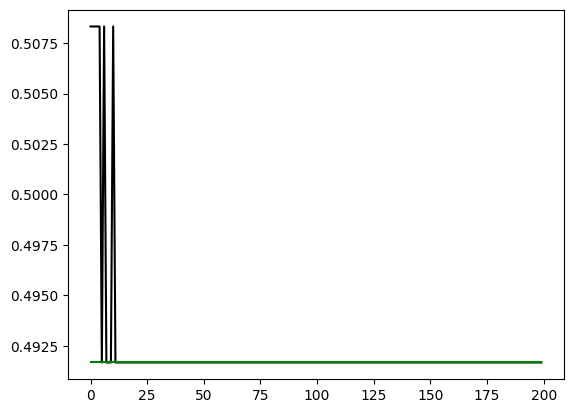

In [ ]:
plt.plot(history1.history['val_accuracy'],color='black')
plt.plot(history2.history['val_accuracy'],color='green')